In [34]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from DATA.stock_invest_function import *
from statsmodels.stats.diagnostic import acorr_ljungbox
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [35]:
import warnings
warnings.filterwarnings("ignore")

In [36]:
# DB 접속 정보 설정
db_info = {
    'user': 'stox7412',         # 예: 'root'
    'password': 'Apt106503!~', # 예: '1234'
    'host': '192.168.0.230',
    # 'host': 'hystox74.synology.me',         # 예: 'localhost' 또는 IP
    'port': '3307',              # 기본 포트는 보통 3306
    'database': 'investar'        # 예: 'trade_data'
}

In [37]:
trade_df = fetch_table_data(db_info, "us_trade_data")

✅ 'us_trade_data' 테이블에서 10774건의 데이터를 가져왔습니다.


In [38]:
trade_df.head(20).to_excel('un_trade_sample.xlsx', index=False)

In [41]:
# 로그 변환을 제거한 상태(use_log=False)로 SARIMA 함수 수정
def forecast_monthly_sarima_final(df, date_col='date', value_col='expDlr', steps=12, use_log=False):
    ts = df.groupby(date_col)[value_col].sum().asfreq('ME')  # 'M' → 'ME'

    if ts.isnull().any() or len(ts.dropna()) < 60:  # 최소 5년(60개월)
        return pd.Series(dtype='float64')

    ts_transformed = np.log(ts) if use_log else ts

    p = d = q = P = D = Q = [0, 1]
    s = 12
    param_combinations = list(product(p, d, q))
    seasonal_combinations = list(product(P, D, Q))
    total_combinations = list(product(param_combinations, seasonal_combinations))

    best_aic = np.inf
    best_model = None
    best_order = None
    best_seasonal = None

    for (order, seasonal) in total_combinations:
        seasonal_order = (*seasonal, s)
        try:
            model = SARIMAX(ts_transformed, order=order, seasonal_order=seasonal_order)
            result = model.fit(disp=False)
            if result.aic < best_aic:
                best_aic = result.aic
                best_order = order
                best_seasonal = seasonal_order
                best_model = result
        except:
            continue

    if best_model is None:
        return pd.Series(dtype='float64')

    forecast_log = best_model.forecast(steps=steps)
    forecast = np.exp(forecast_log) if use_log else forecast_log
    forecast.index = pd.date_range(start=ts.index[-1] + pd.offsets.MonthEnd(1), periods=steps, freq='ME')
    return forecast


In [43]:
# SARIMA 예측 실행 (5년 이상, 로그 변환 X, 경고 제거 O)
forecast_month_list = []

for code in tqdm(valid_codes_monthly, desc="SARIMA 예측 중..."):
    trade_df['hs_code_6d'] = trade_df['hs_code'].astype(str).str[:6]
    sub_df = trade_df[trade_df['hs_code_6d'] == code].copy()
    forecast = forecast_monthly_sarima_final(sub_df[['date', 'expDlr']], steps=14, use_log=False)
    if not forecast.empty:
        temp = pd.DataFrame({
            'hs_code_6d': code,
            'date': forecast.index,
            'expDlr': forecast.values,
            'forecast': 1
        })
        forecast_month_list.append(temp)

# 기존 월별 데이터에 forecast=0
historical_df = trade_df[['hs_code_6d', 'date', 'expDlr']].copy()
historical_df['forecast'] = 0

# 전체 월별 데이터 결합
monthly_combined = pd.concat([historical_df] + forecast_month_list, ignore_index=True)
monthly_combined.sort_values(['hs_code_6d', 'date'], inplace=True)

# 분기별 집계
monthly_combined['quarter'] = monthly_combined['date'].dt.to_period('Q')
quarterly_grouped = (
    monthly_combined
    .groupby(['hs_code_6d', 'quarter', 'forecast'], as_index=False)['expDlr']
    .sum()
)

# 분기 말 날짜 계산
quarterly_grouped['date'] = quarterly_grouped['quarter'].dt.to_timestamp() + pd.offsets.QuarterEnd(0)



SARIMA 예측 중...: 100%|██████████| 73/73 [04:34<00:00,  3.76s/it]


In [45]:
quarterly_grouped_reindex = quarterly_grouped.set_index('date')

<AxesSubplot: xlabel='date'>

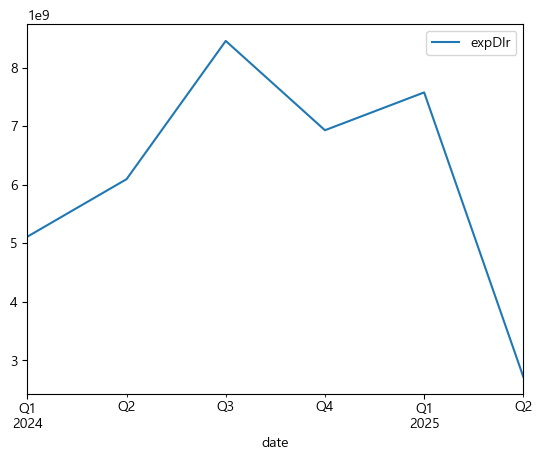

In [49]:
quarterly_grouped_reindex[quarterly_grouped_reindex['hs_code_6d']=='854231'][['expDlr']].plot()

In [48]:
quarterly_grouped_reindex

,hs_code_6d,quarter,forecast,expDlr
date,,,,
2013-03-31,100199,2013Q1,0,2.134413e+09
2013-06-30,100199,2013Q2,0,2.344043e+09
2013-09-30,100199,2013Q3,0,3.045475e+09
2013-12-31,100199,2013Q4,0,1.642240e+09
2014-03-31,100199,2014Q1,0,1.620043e+09
...,...,...,...,...
2025-06-30,988000,2025Q2,1,1.055743e+10
2025-09-30,988000,2025Q3,1,1.601753e+10
2025-12-31,988000,2025Q4,1,1.674860e+10
